# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Naive fit: slope = 2.176+/-0.106, intercept = 22.152+/-0.5588265470965387, reduced chi2 = 42.220


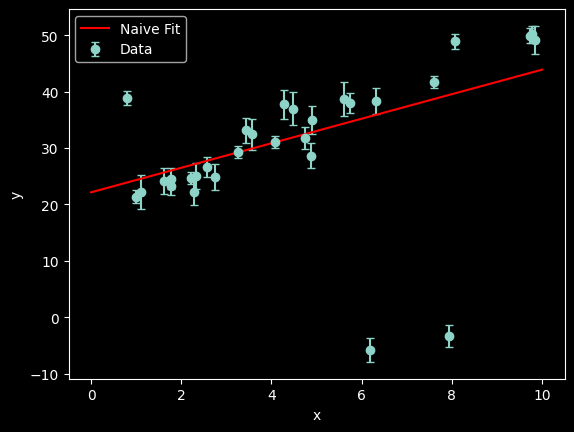

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

netid = 'asteves2'
data = pd.read_csv(f'/Users/andrewsteves/ast457_2026_Fall/labs/01/data/{netid}.csv')
x = data['x']
y = data['y']
sigma = data['sigma_y']

# polyfit fits a polynomial of chosen degree to the passed data
# polyval evaluates a polynomial at a specific value
p, cov = np.polyfit(x, y, 1, w = 1 / sigma, cov = 'unscaled') #setting cov = True returns a coefficient matrix with diagonal entries corresponding to variance coefficients of slope and intercept
residuals = y - np.polyval(p, x)
chi2 = np.sum((residuals / sigma)**2)
chi2_red = chi2 / (len(x) - 2)

stddev_m = np.sqrt(cov[0, 0])
stddev_b = np.sqrt(cov[1, 1])

print(f"Naive fit: slope = {p[0]:.3f}+/-{stddev_m:.3f}, intercept = {p[1]:.3f}+/-{stddev_b}, reduced chi2 = {chi2_red:.3f}")

xx = np.linspace(0, 10, 200)

fig = plt.figure()
plt.errorbar(x, y, yerr = sigma, fmt = 'o', capsize = 3, label = 'Data')
plt.plot(xx, np.polyval(p, xx), color = 'red', label = 'Naive Fit')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.show()

**ANSWER (a few sentences):**

This reduced chi squared test is returning a value in the 40s, which means this model is wildly inaccurate. This error could either be due to a substantial difference between the observed y values and the y values predicted by the model, or the standard deviations are incorrect for this data. Further analysis is necessary to know whether this standard deviation is accurate and the model is inaccurate, or if both are inaccurate.


## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

Sigma-clipping: slope = 3.231+/-0.014, intercept = 18.194+/-0.380, outlier frac = 0.133
Neg. log likelihood: slope = 3.322+/-0.134, intercept = 17.998+/-0.604, outlier frac = 0.156
Sigma clipping Chi2 = 46.015, Mixed model Chi2 = 46.797
Sigma clipping MAD = 1.046, Mixed model MAD = 1.232


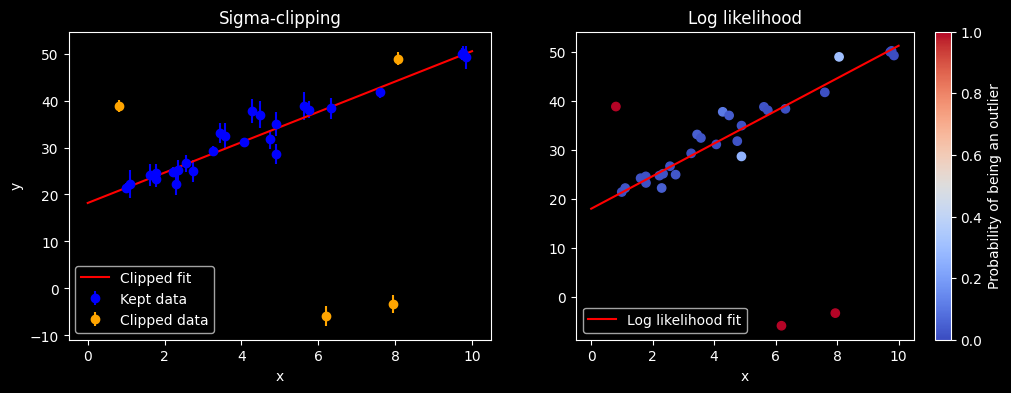

In [77]:
# Part 2: your work here
from scipy.optimize import minimize
from scipy.stats import norm

#Sigma-clipping
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov = 'unscaled')
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask, cov

p_clip, mask, cov_sig_clip = sigma_clip_fit(x, y, sigma, k=3.0)
resid = y[mask] - np.polyval(p_clip, x[mask])

outlier_frac_sig_clip = len(x[~mask]) / len(x)

#Mixture model
def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc = model, scale = sigma)
    bad_pop = Pb * norm.pdf(y, loc = Yb, scale = np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = (p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0))
outputs = minimize(neg_log_likelihood, x0 = theta0, args=(x, y, sigma))
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = outputs.x
cov_mix = np.asarray(outputs.hess_inv)

m_mix_stddev = np.sqrt(cov_mix[0, 0])
b_mix_stddev = np.sqrt(cov_mix[1, 1])

Vb = np.exp(lnVb_mix)
mix_model = m_mix * x + b_mix
good = (1 - Pb_mix) * norm.pdf(y, loc = mix_model, scale = sigma)
bad = Pb_mix * norm.pdf(y, loc = Yb_mix, scale = np.sqrt(Vb + sigma**2))

p_good = good / (good + bad)
p_bad = bad / (bad + good)

n_good = np.sum(p_good)
n_bad = np.sum(p_bad)
outlier_frac_mix = n_bad / n_good

sig_res = y - np.polyval(p_clip, x)
sig_clip_chi2_res = np.sum((sig_res)**2 / sigma**2) / (len(x) - 2)
mad_clip = np.median(np.abs(sig_res - np.median(sig_res)))

mix_res = y - (m_mix * x + b_mix)
mix_chi2_res = np.sum((mix_res)**2 / sigma**2) / (len(x) - 2)
mad_mix = np.median(np.abs(mix_res - np.median(mix_res)))

fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ax[0].errorbar(x[mask], y[mask], yerr = sigma[mask], fmt = 'o', label = 'Kept data', color = 'blue')
ax[0].errorbar(x[~mask], y[~mask], yerr = sigma[~mask], fmt = 'o', label = 'Clipped data', color = 'orange')
ax[0].plot(xx, np.polyval(p_clip, xx), color = 'red', label = 'Clipped fit')

ax[0].set_title('Sigma-clipping')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].legend(loc = 'lower left')

img1= ax[1].scatter(x, y, c = p_bad, cmap = 'coolwarm', vmin = 0, vmax = 1)
ax[1].plot(xx, m_mix * xx + b_mix, color = 'red', label = 'Log likelihood fit')
plt.colorbar(img1, label = 'Probability of being an outlier')

ax[1].set_title('Log likelihood')
ax[1].set_xlabel('x')
ax[1].legend(loc = 'lower left')

print(f'Sigma-clipping: slope = {p_clip[0]:.3f}+/-{cov_sig_clip[0, 0]:.3f}, intercept = {p_clip[1]:.3f}+/-{cov_sig_clip[1, 1]:.3f}, outlier frac = {outlier_frac_sig_clip:.3f}')
print(f'Neg. log likelihood: slope = {m_mix:.3f}+/-{m_mix_stddev:.3f}, intercept = {b_mix:.3f}+/-{b_mix_stddev:.3f}, outlier frac = {outlier_frac_mix:.3f}')
print(f'Sigma clipping Chi2 = {sig_clip_chi2_res:.3f}, Mixed model Chi2 = {mix_chi2_res:.3f}')
print(f'Sigma clipping MAD = {mad_clip:.3f}, Mixed model MAD = {mad_mix:.3f}')

**FINAL ANSWER:** $m = $ 3.231 $\pm$ 0.014 , $b = $ 18.194 $\pm$ 0.380 , outlier fraction $\approx$ 0.133

**Justification and uncertainty method (a short paragraph):**

*I believe the sigma-clipping model works better for this data because it has smaller uncertainties for both the slope and intercept of the best fit line. Having smaller deviations may mean that there is high precision with the trend line, and thus a more accurate fit. It also has a smaller mean absolute deviation, predicting that the data points are closer to the mean. It should be said however that both fits are likely not very accurate having xhi2 scores both in the mid to upper 40s.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1: Reducing chi squared by a constant factor simply to pass the test of having a reduced chi squared of 1.00*

*Flaw 2: The statement about the fit of the line looking good is not substantial evidence for an actually good fit*

*Flaw 3: The plot uses the scaled standard deviations for error bars rather than the known standard deviations for the y-values of each data point*

Reduced chi2 = 1.000


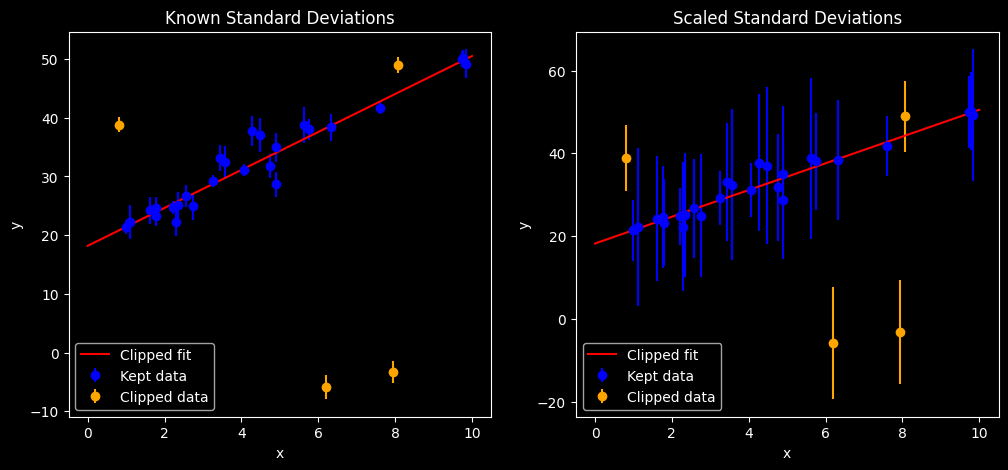

In [11]:
# Part 3: demonstrations here

# Flaw 1: reduced chi squared error
scale = np.sqrt(chi2_red)
sigma_scaled = sigma * scale
chi2_red_new = np.sum((residuals / sigma_scaled)**2) / (len(x) - 2)
print(f'Reduced chi2 = {chi2_red_new:.3f}')
# Rescaling by the square root of the reduced chi squared will always guarantee a reduced chi squared value of 1. The test describes how well a model fits a dataset, so rescaling to always achive the desired value
# renders the test useless.

# Flaw 2: Statement about quality of fit
# The AI returned a chi2 value of 8.468, which indicates a poor fit to the data despite the least squares fit seemingly fitting the data well.

# Flaw 3: Incorrect error bars
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].errorbar(x[mask], y[mask], yerr = sigma[mask], fmt = 'o', label = 'Kept data', color = 'blue')
ax[0].errorbar(x[~mask], y[~mask], yerr = sigma[~mask], fmt = 'o', label = 'Clipped data', color = 'orange')
ax[0].plot(xx, np.polyval(p_clip, xx), color = 'red', label = 'Clipped fit')

ax[0].set_title('Known Standard Deviations')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].legend(loc = 'lower left')

ax[1].errorbar(x[mask], y[mask], yerr = sigma_scaled[mask], fmt = 'o', label = 'Kept data', color = 'blue')
ax[1].errorbar(x[~mask], y[~mask], yerr = sigma_scaled[~mask], fmt = 'o', label = 'Clipped data', color = 'orange')
ax[1].plot(xx, np.polyval(p_clip, xx), color = 'red', label = 'Clipped fit')

ax[1].set_title('Scaled Standard Deviations')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].legend(loc = 'lower left')
# The treatment for this is the same as the first flaw, rescaling the error in this manner is arbitrary and unnecessary.

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*AI (Copilot) was only used for minor debugging and resolving errors.*

**VERIFICATION PLAN:**

*To verify this model, I primarily used MAD and chi squared statistics to drive my analysis, and general sanity checks to ensure that fits look correct on first inspection. I tried to use residual plots, however I couldn't find any meaningful information from them as they all appeared to be identical.*